# DAU 차트를 봐서는 DAU를 올릴 수 없다 — 유저 세그먼트 분석 실습

DAU 한 줄짜리 그래프로는 신규 유저의 안착도, 헤비 유저의 이탈 징후도, 잠들었던 유저의 부활도
모두 한 점으로 뭉개져 보이지 않습니다. 이 노트북은 유저를 **7개 세그먼트**로 쪼개고,
세그먼트 사이의 **이동(Flow)** 과 비율 지표로 서비스 건강도를 입체적으로 들여다봅니다.
그림과 표가 꽤나 복잡해 보이지만, 막상 SQL로 옮겨 보면 의외로 단순한 데이터 구조 위에서
돌아간다는 사실을 확인할 수 있습니다.

분석은 두 개의 원천 테이블에서 출발합니다.

| 테이블 | 입자 단위 | 역할 |
| :-- | :-- | :-- |
| `user_master` | user_id (유저당 1행) | 유저별 가입(첫 접속) 정보 — 언제 처음 우리 서비스를 만났는가 |
| `user_activity` | user_id × event_date | 유저별 일별 접속 기록 — 어느 날 우리 서비스를 다시 방문했는가 |

- **실습 1.** 두 테이블에서 4개 파생지표(`is_newbie`, `d0_active`, `active_day_count`, `last_active_date`)를 만들고, 정해진 기준에 따라 7개 세그먼트로 분류합니다.
- **실습 2.** 어제·오늘 두 시점의 세그먼트를 한 행에 담아, 세그먼트 변화를 추적할 수 있는 마트를 만듭니다.
- **실습 3.** 그 마트를 분포(Stock) · 전이 행렬(Flow) · 비율 지표(HURR/CURR/Heavy Loss/Light Loss/Reactivation) 세 각도로 분석합니다.
- **실습 4.** 마트를 여러 날 적재해, 30일 전 heavy 유저가 오늘 어디로 흩어졌는지 N일 변화를 추적합니다.

쿼리는 모두 **DuckDB**로 예시 CSV에 직접 실행합니다.

## 0. 준비

아래 셀은 의존성 설치와 실습 환경(연결·상수·테이블 등록)을 한 번에 구성합니다.
데이터가 없다면 먼저 터미널에서 `python generate_data.py` 를 실행해 예시 데이터를
만들어 주세요 (`data/user_master.csv`, `data/user_activity.csv`).

> **[내 데이터 적용]** 분석 기준일(`TARGET`)을 내 날짜로 바꿉니다. 단, 쿼리들에는
> `'2026-05-20'` 이 문자열로 박혀 있어 기준일을 바꾸려면 각 쿼리의 날짜도 함께 바꿔야
> 합니다(실습 4처럼 `.replace` 로 일괄 치환해도 됩니다).

## 실습용 데이터 준비

실습에는 유저별 가입 정보가 기록된 `user_master` 와, 유저의 행동 로그가 기록된
`user_activity` 두 테이블이 필요합니다. 굳이 두 테이블로 분리해 두는 이유는, 담고 있는
데이터의 성격이 다르기 때문입니다. 첫 접속일은 유저당 한 번만 기록되는 정적 마스터
테이블이고, 일별 접속은 매일 새로 쌓이는 로그 테이블입니다. 갱신 주기도, 사용되는 맥락도
다른 두 데이터를 한 테이블에 한꺼번에 담지 않는 편이 마트 운영과 분석 모두에 더 유리합니다.

두 CSV는 아래 셀에서 DuckDB 테이블로 등록해 두고, 이후 모든 쿼리에서 테이블 이름으로
참조합니다. DuckDB는 별도 서버 설치 없이 파이썬 안에서 바로 SQL을 돌릴 수 있는 가벼운
분석용 DB인데요. 여기서 쓰는 SQL은 거의 표준 문법이라, 사내 웨어하우스(BigQuery,
Redshift 등)로 옮길 때도 함수 몇 개만 손보면 됩니다.

> **[내 데이터 적용]** 내 서비스의 두 테이블로 바꿉니다 —
> `user_master(user_id, first_active_date)`, `user_activity(user_id, event_date)`.

In [1]:
# 의존성 설치 및 실습 환경 구성
%pip install -q -r requirements.txt

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()   # 인메모리 연결 하나를 노트북 전체에서 재사용
SEG_ORDER = ["new", "heavy_active", "light_active",
             "heavy_inactive", "light_inactive", "risk", "dormant"]
TARGET = "2026-05-20"    # 분석 기준일(아래 SQL에는 이 날짜가 문자열로 직접 박혀 있어서, 기준일을 바꾸려면 각 쿼리의 날짜도 함께 바꿔야 함)

# CSV 두 개를 테이블로 한 번만 등록 — 이후 쿼리는 user_master / user_activity 로 참조
con.execute("CREATE TABLE user_master   AS SELECT * FROM read_csv_auto('data/user_master.csv')")
con.execute("CREATE TABLE user_activity AS SELECT * FROM read_csv_auto('data/user_activity.csv')")
con.execute("SELECT * FROM user_activity").df().head()


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


,user_id,event_date
0,user_032,2026-01-27
1,user_144,2026-01-27
2,user_144,2026-01-28
3,user_123,2026-01-29
4,user_144,2026-01-29


## 실습 1. 4개의 파생지표로 7개 세그먼트 분류하기

`user_master` 혹은 `user_activity` 테이블만 살펴봐서는 개별 유저가 어떤 세그먼트에
속하는지 파악하기 어렵습니다. 이 두 테이블은 어디까지나 분석을 위한 기초 데이터일 뿐이고,
세그먼트 구분을 위해서는 한 단계의 가공이 더 필요합니다.

7개 세그먼트(new, heavy_active, light_active, heavy_inactive, light_inactive, risk,
dormant)는 결국 다음 4개의 축으로 결정됩니다.

| 축 | 의미 |
| :-- | :-- |
| `is_newbie` | 오늘이 첫 접속일인가? |
| `d0_active` | 오늘 접속했는가? |
| `active_day_count` | 최근 7일 중 며칠 접속했는가? |
| `last_active_date` | 가장 최근 접속일은? |

`user_master` 와 `user_activity` 를 `LEFT JOIN` 한 뒤 유저 단위로 집계하면 4개 파생지표를
한번에 만들 수 있습니다. 결과는 `user_metrics` 테이블에 담아 두고, 다음 단계의 분류 쿼리가
이 테이블을 입력으로 씁니다.

쿼리에 나오는 `bool_or`, `count_if` 는 '조건을 만족하는 행이 하나라도 있는가',
'조건을 만족하는 행이 몇 개인가'를 세는 DuckDB 집계 함수입니다. 만약 사내 데이터
웨어하우스가 이 함수를 지원하지 않는다면 각각 `MAX(CASE WHEN … THEN 1 ELSE 0 END)`,
`SUM(CASE WHEN … THEN 1 ELSE 0 END)` 로 바꿔 쓰면 됩니다.

In [2]:
# 4개 파생지표 만들기 — user_master 와 user_activity 를 LEFT JOIN 해 유저 단위로 집계
con.execute("""
CREATE OR REPLACE TABLE user_metrics AS
SELECT
  m.user_id,
  -- 1. 오늘 가입한 유저 여부
  (m.first_active_date = DATE '2026-05-20') AS is_newbie,
  -- 2. 오늘 접속 여부
  bool_or(a.event_date = DATE '2026-05-20') AS d0_active,
  -- 3. 최근 7일(기준일 포함) 접속 일수
  count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                            AND DATE '2026-05-20') AS active_day_count,
  -- 4. 마지막 활동일 (가입 당일 활동이 보장되므로 항상 존재)
  max(CASE WHEN a.event_date <= DATE '2026-05-20' THEN a.event_date END) AS last_active_date
FROM user_master m LEFT JOIN user_activity a USING (user_id)
GROUP BY m.user_id, m.first_active_date
""")
con.execute("SELECT * FROM user_metrics ORDER BY user_id").df().head()

,user_id,is_newbie,d0_active,active_day_count,last_active_date
0,user_001,True,True,1.0,2026-05-20
1,user_002,True,True,1.0,2026-05-20
2,user_003,True,True,1.0,2026-05-20
3,user_004,True,True,1.0,2026-05-20
4,user_005,True,True,1.0,2026-05-20


이제 위에서 만든 `user_metrics` 의 4개 지표를 **정해진 기준**에 따라 `CASE WHEN` 한 단계로
7개 세그먼트로 분류합니다. 분류 기준은 다음과 같습니다.

| 세그먼트 | 분류 기준 |
| :-- | :-- |
| `new` | 오늘 가입 (`is_newbie`) |
| `heavy_active` | 오늘 접속 & 최근 7일 5일 이상 |
| `light_active` | 오늘 접속 & 최근 7일 1~4일 |
| `heavy_inactive` | 오늘 미접속 & 최근 7일 5일 이상 |
| `light_inactive` | 오늘 미접속 & 최근 7일 1~4일 |
| `risk` | 최근 7일 0일 & 마지막 접속 7~30일 전 |
| `dormant` | 최근 7일 0일 & 마지막 접속 30일 초과 |

> risk·dormant 분기는 마지막 접속일만으로 가릅니다 — `active_day_count = 0` 이면
> 최근 7일 접속이 없다는 뜻이라, 오늘 접속 여부도 '마지막 접속이 7일 이전인지'도
> 따로 검사할 필요가 없기 때문입니다.

In [3]:
# 정해진 기준에 따라 7개 세그먼트로 분류 — 위에서 만든 user_metrics 를 입력으로 사용
seg = con.execute("""
SELECT
  *,
  CASE
    WHEN is_newbie                                          THEN 'new'
    WHEN d0_active     AND active_day_count >= 5            THEN 'heavy_active'
    WHEN d0_active     AND active_day_count BETWEEN 1 AND 4 THEN 'light_active'
    WHEN NOT d0_active AND active_day_count >= 5            THEN 'heavy_inactive'
    WHEN NOT d0_active AND active_day_count BETWEEN 1 AND 4 THEN 'light_inactive'
    -- active_day_count = 0 이면 최근 7일 접속이 없다는 뜻이므로,
    -- risk/dormant 는 마지막 활동일이 30일 안쪽인지로만 가르면 된다.
    WHEN last_active_date >= DATE '2026-05-20' - INTERVAL 30 DAY THEN 'risk'
    ELSE 'dormant'
  END AS user_seg
FROM user_metrics
ORDER BY user_id;
""").df()
print(seg["user_seg"].value_counts().reindex(SEG_ORDER))

user_seg
new               10
heavy_active      30
light_active      30
heavy_inactive     9
light_inactive    48
risk              53
dormant           20
Name: count, dtype: int64


7개 세그먼트가 모두 등장하도록 각 세그먼트에서 한 명씩 뽑아 보면, 4개 지표가
어떻게 하나의 세그먼트로 압축되는지 한눈에 들어옵니다.

In [4]:
# 각 세그먼트의 대표 유저를 한 명씩 발췌
sample = seg.groupby("user_seg").first().reindex(SEG_ORDER).reset_index()
sample[["user_seg", "user_id", "is_newbie", "d0_active", "active_day_count", "last_active_date"]]

,user_seg,user_id,is_newbie,d0_active,active_day_count,last_active_date
0,new,user_001,True,True,1.0,2026-05-20
1,heavy_active,user_017,False,True,6.0,2026-05-20
2,light_active,user_016,False,True,3.0,2026-05-20
3,heavy_inactive,user_022,False,False,5.0,2026-05-19
4,light_inactive,user_011,False,False,1.0,2026-05-16
5,risk,user_021,False,False,0.0,2026-04-22
6,dormant,user_026,False,False,0.0,2026-04-16


## 실습 2. 세그먼트 변화 추적 가능한 데이터 마트 만들기

실습 1의 결과는 어느 한 시점의 스냅샷, 즉 **Stock** 에 해당합니다. 이 테이블이 있으면 기준
시점에 유저들이 각 세그먼트에 어떻게 분포돼 있는지를 확인할 수 있습니다. 하지만 아래와 같은
질문에 답하려면, **어제와 오늘 두 시점의 세그먼트를 한 행에 나란히 담아둔 데이터 마트**가
필요합니다.

1. 어제 heavy였던 유저 중 몇 명이 오늘 light로 떨어졌는가? (Heavy Loss)
2. 어제 risk였던 유저 중 누가 오늘 다시 활동으로 돌아왔는가? (Reactivation)
3. 어제 heavy였던 유저는 오늘도 heavy로 잘 남아 있는가? (HURR)

먼저 실습 1의 분류 CASE를 기준일을 인자로 받는 **매크로**로 정의합니다. 오늘과 어제,
두 시점의 분류가 필요한데 같은 기준을 두 번 복사하는 대신 한 번 정의해 재사용하려는
것입니다.

> **[내 데이터 적용]** 임계값(heavy 컷·경계일)을 내 서비스에 맞게 바꿀 때는 실습 1의
> 분류 CASE와 이 매크로 **두 곳을 똑같이** 고칩니다.

In [5]:
# 실습 1의 분류 CASE를 매크로로 정의 — 오늘/어제 두 시점에 재사용합니다.
con.execute("""
CREATE OR REPLACE MACRO classify_seg(is_newbie, d0_active, cnt, last_active, ref_date) AS
  CASE
    WHEN is_newbie                             THEN 'new'
    WHEN d0_active     AND cnt >= 5            THEN 'heavy_active'
    WHEN d0_active     AND cnt BETWEEN 1 AND 4 THEN 'light_active'
    WHEN NOT d0_active AND cnt >= 5            THEN 'heavy_inactive'
    WHEN NOT d0_active AND cnt BETWEEN 1 AND 4 THEN 'light_inactive'
    -- cnt = 0 이면 최근 7일 접속이 없으므로 risk/dormant 는 마지막 활동일로만 가른다.
    WHEN last_active >= ref_date - INTERVAL 30 DAY THEN 'risk'
    ELSE 'dormant'
  END
""")

아래 쿼리는 4개 지표를 오늘·어제 두 시점으로 계산해 `user_seg`(오늘)와
`user_seg_from`(어제)을 한 행에 담고, 그 결과를 `mart_user_segment` 테이블로 적재합니다.

In [6]:
build_mart_query = """
-- 4개 파생지표를 오늘/어제 두 시점으로 계산해 세그먼트 마트를 적재한다. 기준일 2026-05-20.
-- 오늘 막 가입한 신규는 '어제' 기록이 없으므로 user_seg_from 이 NULL 이 된다.
CREATE OR REPLACE TABLE mart_user_segment AS
WITH metrics AS (
  SELECT
    m.user_id,
    -- 오늘(기준일) 지표
    (m.first_active_date = DATE '2026-05-20') AS is_newbie,
    bool_or(a.event_date = DATE '2026-05-20') AS d0_active,
    count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 6 DAY
                              AND DATE '2026-05-20') AS cnt,
    max(CASE WHEN a.event_date <= DATE '2026-05-20' THEN a.event_date END) AS last_active,
    -- 어제 지표 (같은 정의에서 윈도우만 하루 미룸)
    (m.first_active_date = DATE '2026-05-20' - INTERVAL 1 DAY) AS is_newbie_from,
    bool_or(a.event_date = DATE '2026-05-20' - INTERVAL 1 DAY) AS d0_active_from,
    count_if(a.event_date BETWEEN DATE '2026-05-20' - INTERVAL 7 DAY
                              AND DATE '2026-05-20' - INTERVAL 1 DAY) AS cnt_from,
    max(CASE WHEN a.event_date <= DATE '2026-05-20' - INTERVAL 1 DAY THEN a.event_date END) AS last_active_from
  FROM user_master m LEFT JOIN user_activity a USING (user_id)
  GROUP BY m.user_id, m.first_active_date
)
SELECT
  DATE '2026-05-20' AS target_date, user_id,
  classify_seg(is_newbie_from, d0_active_from, cnt_from, last_active_from,
               DATE '2026-05-20' - INTERVAL 1 DAY) AS user_seg_from,
  classify_seg(is_newbie, d0_active, cnt, last_active, DATE '2026-05-20') AS user_seg
FROM metrics ORDER BY user_id;
"""
con.execute(build_mart_query)

적재가 잘 됐는지, 어제→오늘 변화가 뚜렷한 유저 몇 명만 골라 확인해 보겠습니다.

In [7]:
watch = ["user_015", "user_017", "user_022", "user_028", "user_048"]
con.execute("SELECT user_id, user_seg_from, user_seg FROM mart_user_segment").df() \
   .query("user_id in @watch")

,user_id,user_seg_from,user_seg
14,user_015,light_active,light_inactive
16,user_017,heavy_inactive,heavy_active
21,user_022,heavy_active,heavy_inactive
27,user_028,light_inactive,light_active
47,user_048,heavy_inactive,light_inactive


15번 유저는 주 1~4회 정도 접속하는 라이트 유저인데, 어제는 접속했지만 오늘은 접속하지
않은 것을 확인할 수 있습니다. 17번 유저는 주 5일 이상 들어오는 헤비 유저이고, 어제는
미접속했지만 오늘은 다시 접속했네요. 48번 유저는 원래 헤비 유저였지만, 미접속 일수가
늘어나면서 라이트 유저 군으로 재분류된 것이 보입니다. 재방문을 유도하기 위한 액션이
필요한 시점이네요.

## 실습 3. Stock과 Flow 분석하기

이렇게 만든 데이터 마트가 매일 적재되어 누적된다고 가정하면, 이 마트 하나로 한 시점의
**분포(Stock)** 와 시점 간 **이동(Flow)**, 그리고 그 이동을 요약한 **비율 지표(KPI)** 를
모두 분석할 수 있습니다.

### Stock — 일별 세그먼트 분포

가장 먼저 확인할 수 있는 건 **한 시점에 우리 서비스의 유저들이 어떤 분포로 존재하는가**
입니다. 단순한 `GROUP BY` 한 번이면 계산할 수 있습니다.

,users
user_seg,
new,10
heavy_active,30
light_active,30
heavy_inactive,9
light_inactive,48
risk,53
dormant,20


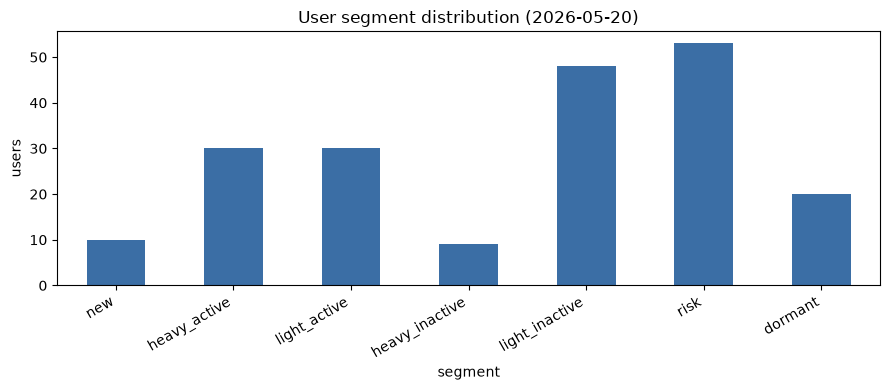

In [8]:
# 일별 세그먼트 분포 (Stock) — 정렬은 pandas reindex 가 담당
dist = con.execute("""
SELECT user_seg, count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
GROUP BY user_seg
""").df().set_index("user_seg").reindex(SEG_ORDER)
display(dist)

ax = dist["users"].plot.bar(figsize=(9, 4), color="#3b6ea5")
ax.set_title("User segment distribution (2026-05-20)")
ax.set_xlabel("segment"); ax.set_ylabel("users")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

이 표는 *오늘* 우리 서비스의 유저들이 어디에 모여 있는지를 보여주는
횡단면(cross-section)입니다. 지금은 마트에 하루치 데이터만 들어 있지만, 실습 4까지 진행한
후 `target_date` 를 바꿔가며 같은 쿼리를 돌려 보면 세그먼트 구성이 어떻게 달라지는지
관찰할 수 있습니다. 가령 heavy_active의 절대 수가 줄고 있는데 light_inactive가 같이 늘고
있다면, 헤비 유저의 이탈이 서서히 진행되고 있다는 신호로 읽을 수 있겠죠.

### Flow — 세그먼트 전이 행렬

Stock 만 봐서는, heavy_active 의 수가 어제와 비슷하게 유지된다고 해도 그게 그대로 남은
유저인지 빠진 자리를 다른 유저가 채운 건지 구별할 수 없습니다. 그 차이를 보려면 세그먼트
전이 행렬을 만들어서 보는 게 간편합니다. 다행히 우리가 만든 데이터 마트에는 그 정보가
이미 들어 있습니다 — 어제(`user_seg_from`)를 행, 오늘(`user_seg`)을 열로 펼치면
전이 행렬이 됩니다.

In [9]:
# 세그먼트 전이 (Flow): 어제(user_seg_from) → 오늘(user_seg)
trans = con.execute("""
SELECT user_seg_from, user_seg, count(*) AS users
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20'
  AND user_seg_from IS NOT NULL   -- 오늘 처음 가입한 신규(어제 NULL)는 별도 분석
  AND user_seg_from <> 'new'      -- 어제 막 가입한 신규도 전이 분석에서는 제외
GROUP BY user_seg_from, user_seg
""").df()

order = ["heavy_active", "light_active", "heavy_inactive", "light_inactive", "risk", "dormant"]
pivot = (trans.pivot(index="user_seg_from", columns="user_seg", values="users")
              .reindex(index=order, columns=order))
pivot.fillna(0).astype(int)

user_seg,heavy_active,light_active,heavy_inactive,light_inactive,risk,dormant
user_seg_from,,,,,,
heavy_active,21,0,9,1,0,0
light_active,2,8,0,16,0,0
heavy_inactive,6,0,0,2,0,0
light_inactive,1,21,0,29,4,0
risk,0,1,0,0,49,1
dormant,0,0,0,0,0,19


이 행렬을 히트맵으로 그리면 전이가 어디에 몰려 있는지 한눈에 들어옵니다.

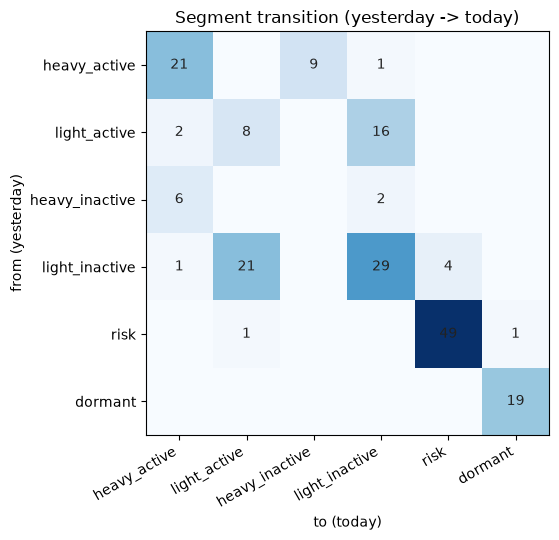

In [10]:
# 전이 행렬 히트맵
m = pivot.values.astype(float)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.imshow(np.nan_to_num(m), cmap="Blues")
ax.set_xticks(range(len(order)), order, rotation=30, ha="right")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("to (today)"); ax.set_ylabel("from (yesterday)")
for i in range(len(order)):
    for j in range(len(order)):
        if not np.isnan(m[i, j]):
            ax.text(j, i, int(m[i, j]), ha="center", va="center", color="#222")
ax.set_title("Segment transition (yesterday -> today)")
plt.tight_layout(); plt.show()

행과 열이 모두 활동성이 높은 순(왼쪽·위)에서 낮은 순(오른쪽·아래)으로 정렬되어 있는데요.
아래와 같이 세 가지 방향으로 이 행렬을 읽어서 해석하면 됩니다.

1. **대각선**: 어제와 오늘의 세그먼트가 같은 유저들. 안정적으로 유지되고 있음을 의미.
2. **대각선 위쪽** (같은 행에서 오른쪽 셀): 활동성이 떨어진 유저들
   (예: heavy_active → light_inactive, light_active → risk). 이탈 징후로 모니터링해야 할 영역.
3. **대각선 아래쪽** (같은 행에서 왼쪽 셀): 활동성이 더 높아진 유저들
   (예: light_active → heavy_active, risk → light_active). 긍정적 전이로 볼 수 있는 영역.

### 비율 지표 (KPI)

전이 행렬에서 여러 가지 의미 있는 비율 지표들을 뽑아낼 수 있습니다. 몇 가지 예시를 들면
아래와 같습니다.

1. **HURR (Heavy → Heavy)**: Heavy 유저의 유지율
2. **CURR (Heavy + Light → Heavy + Light)**: Heavy+Light 유저의 유지율
3. **Heavy Loss (Heavy → Light)**: Heavy 에서 Light 유저로 전이된 비율
4. **Light Loss (Light → Risk)**: Light 에서 Risk 유저로 전이된 비율
5. **Reactivation (Risk → Light)**: Risk 에서 Light 유저로 전이된 비율

heavy·light 세그먼트 묶음은 앞으로도 계속 쓰게 되므로, SQL에 끼워 넣을 문자열
상수(`heavy`/`light`/`core`)로 정의해 두고 실습 4에서도 재사용합니다.

In [11]:
heavy = "('heavy_active', 'heavy_inactive')"
light = "('light_active', 'light_inactive')"
core  = "('heavy_active', 'heavy_inactive', 'light_active', 'light_inactive')"

# 분모가 0이 되는 경우를 막기 위해 nullif(..., 0) 으로 감싼다.
kpi = con.execute(f"""
SELECT
  round(count_if(user_seg_from IN {heavy} AND user_seg IN {heavy})
        / nullif(count_if(user_seg_from IN {heavy}), 0) * 100, 1)  AS hurr_pct,
  round(count_if(user_seg_from IN {core}  AND user_seg IN {core})
        / nullif(count_if(user_seg_from IN {core}), 0) * 100, 1)   AS curr_pct,
  round(count_if(user_seg_from IN {heavy} AND user_seg IN {light})
        / nullif(count_if(user_seg_from IN {heavy}), 0) * 100, 1)  AS heavy_loss_pct,
  round(count_if(user_seg_from IN {light} AND user_seg = 'risk')
        / nullif(count_if(user_seg_from IN {light}), 0) * 100, 1)  AS light_loss_pct,
  round(count_if(user_seg_from = 'risk' AND user_seg IN {light})
        / nullif(count_if(user_seg_from = 'risk'), 0) * 100, 1)    AS reactivation_pct
FROM mart_user_segment
WHERE target_date = DATE '2026-05-20';
""").df()
kpi.T.rename(columns={0: "pct"})

,pct
hurr_pct,92.3
curr_pct,96.7
heavy_loss_pct,7.7
light_loss_pct,4.9
reactivation_pct,2.0


각 숫자가 어떤 의미를 가지고 있는지를 다시 한번 정리하면 다음과 같습니다.

| 지표 | 의미 |
| :-- | :-- |
| HURR 92.3% | 어제 heavy 였던 유저 중 92.3%가 오늘도 heavy (유지) |
| CURR 96.7% | 어제 heavy·light 였던 핵심 활동 유저 중 96.7%가 오늘도 동일하게 남아 있음 |
| Heavy Loss 7.7% | 어제 heavy 였던 유저 중 7.7%가 light 로 내려감 |
| Light Loss 4.9% | 어제 light 였던 유저 중 4.9%가 risk 로 이탈 |
| Reactivation 2.0% | 어제 risk 였던 유저 중 2.0%가 다시 light 로 복귀 |

이처럼 쿼리 한 번으로 다양한 비율 지표를 동시에 추출할 수 있습니다. 이러한 지표들을
일별로 차곡차곡 쌓아두면, 단순한 DAU 트렌드와는 비교할 수 없는 해상도로 서비스의 건강
상태를 모니터링할 수 있게 됩니다. 여기서 유의해야 하는 점은, 비율 지표를 해석할 때
**분모의 크기**를 반드시 함께 봐야 한다는 점입니다. 가령 위 예시에서 Reactivation 2.0%는
risk 유저 51명 중 단 1명이 돌아온 결과인데요. 애초에 인원이 적은 세그먼트의 비율은 한두
명만 움직여도 수치가 크게 출렁일 수 있습니다. 그래서 실무에서는 비율 지표를 확인할 때
분모(세그먼트 규모)를 나란히 표기하거나, 하루치가 아니라 일정 기간을 누적해 분모를 키운
뒤 해석하는 편이 보다 안전합니다.

## 실습 4. N일 후 세그먼트 변화 추적

여기까지의 분석은 모두 어제와 오늘, 즉 1일 단위의 변화를 들여다보는 데 집중했습니다.
1일 단위는 마트 갱신 주기와 잘 맞고 즉시성이 높다는 장점이 있지만, 막상 들여다보면 변화의
폭이 너무 작아서 의미 있는 패턴이 잘 드러나지 않는다는 단점도 있습니다. 어제 heavy였던
유저가 오늘도 heavy일 확률이 거의 90%를 웃돌다 보니, HURR 92.3%라는 숫자만으로는 우리
서비스의 헤비 유저 충성도가 정말로 견고한 건지 가늠하기 어렵습니다.

이때 시간 축을 좀 더 길게 잡고 패턴을 살펴보면 세그먼트 간의 전이를 파악하는 데 큰 도움이
됩니다. 예를 들면 30일 전에 신규로 가입한 new 유저의 세그먼트 정보가 오늘은 어떻게
분포되어 있는지를 본다든가, 30일 전에 heavy 였던 유저들이 오늘 어떤 세그먼트로 나뉘어져
있는지를 보는 식입니다.

우선 실습 2의 마트 쿼리를 기준일만 바꿔가며 한 달치를 적재합니다. 운영 환경에서 마트가
매일 쌓이는 것을 그대로 흉내 내는 셈입니다.

> **[내 데이터 적용]** 적재할 일수(`periods=31`)를 N일 추적 구간에 맞게 늘립니다
> (예: 60·90일 추적이면 더 길게).

In [12]:
# 실습 2의 마트 쿼리를 기준일만 바꿔 2026-04-20 ~ 2026-05-20 (31일치) 적재
con.execute("DROP TABLE IF EXISTS mart_user_segment")
for i, t in enumerate(pd.date_range(end=TARGET, periods=31)):
    q = build_mart_query.replace("2026-05-20", t.date().isoformat())
    if i > 0:
        q = q.replace("CREATE OR REPLACE TABLE mart_user_segment AS",
                      "INSERT INTO mart_user_segment BY NAME")
    con.execute(q)

con.execute("SELECT count(DISTINCT target_date) AS n_days, count(*) AS n_rows "
            "FROM mart_user_segment").df()

,n_days,n_rows
0,31,6200


이제 두 시점(30일 전 · 오늘)을 `user_id` 로 self-join 하면, 30일 전 **heavy**(heavy_active +
heavy_inactive) 유저가 오늘 어느 세그먼트로 흩어졌는지가 한 표로 나옵니다.

,seg_30days_ago,seg_today,users,pct
0,heavy_all,heavy_active,24,51.1
1,heavy_all,risk,9,19.1
2,heavy_all,light_inactive,6,12.8
3,heavy_all,light_active,6,12.8
4,heavy_all,heavy_inactive,2,4.3


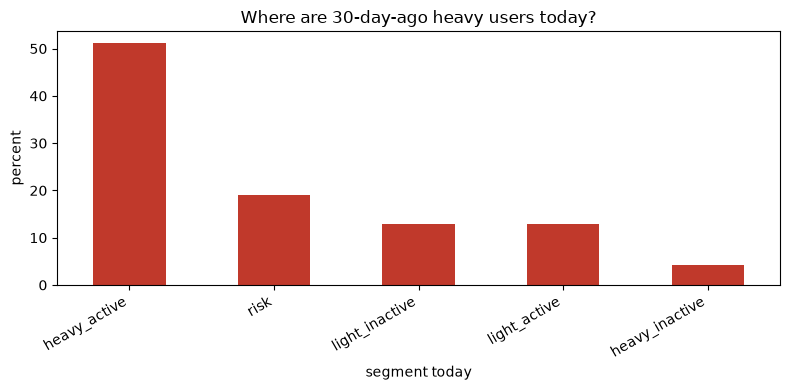

In [13]:
# 30일 전 heavy(=heavy_active + heavy_inactive) 유저가 오늘은 어디에 있는가
# (past.user_seg 를 'new' 로 바꾸면 신규 유저의 N일 안착 패턴을 볼 수 있다)
nday = con.execute(f"""
SELECT
  'heavy_all' AS seg_30days_ago,
  curr.user_seg AS seg_today,
  count(*) AS users,
  round(count(*) / sum(count(*)) OVER () * 100, 1) AS pct
FROM mart_user_segment AS past
LEFT JOIN mart_user_segment AS curr
  ON past.user_id = curr.user_id
 AND curr.target_date = DATE '2026-05-20'
WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
  AND past.user_seg IN {heavy}
GROUP BY curr.user_seg
ORDER BY users DESC;
""").df()
display(nday)

ax = nday.set_index("seg_today")["pct"].plot.bar(figsize=(8, 4), color="#c0392b")
ax.set_title("Where are 30-day-ago heavy users today?")
ax.set_xlabel("segment today"); ax.set_ylabel("percent")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

30일 전 heavy 유저의 절반 가까이가 다른 세그먼트로 흩어졌습니다. 이걸 **같은 HURR 기준**으로
1일 변화와 나란히 놓고 비교해 보겠습니다 — 둘 다 *heavy(heavy_active + heavy_inactive) 유지율*입니다.

In [14]:
# 같은 'heavy 유지율(HURR)' 을 1일 / 30일 두 시간 축으로 비교
hurr_compare = con.execute(f"""
WITH one_day AS (    -- 어제 heavy → 오늘 heavy
  SELECT round(count_if(user_seg_from IN {heavy} AND user_seg IN {heavy})
               / nullif(count_if(user_seg_from IN {heavy}), 0) * 100, 1) AS hurr_pct
  FROM mart_user_segment
  WHERE target_date = DATE '2026-05-20'
),
thirty_day AS (      -- 30일 전 heavy → 오늘 heavy
  SELECT round(count_if(curr.user_seg IN {heavy})
               / nullif(count(*), 0) * 100, 1) AS hurr_pct
  FROM mart_user_segment AS past
  LEFT JOIN mart_user_segment AS curr
    ON past.user_id = curr.user_id AND curr.target_date = DATE '2026-05-20'
  WHERE past.target_date = DATE '2026-05-20' - INTERVAL 30 DAY
    AND past.user_seg IN {heavy}
)
SELECT '1일 (어제 → 오늘)'     AS horizon, hurr_pct FROM one_day
UNION ALL
SELECT '30일 (30일 전 → 오늘)', hurr_pct FROM thirty_day
""").df()
hurr_compare

,horizon,hurr_pct
0,1일 (어제 → 오늘),92.3
1,30일 (30일 전 → 오늘),55.3


1일 기준으로는 heavy 유저의 **92.3%**가 다음 날에도 heavy로 남지만, 같은 heavy 그룹을 **30일**
기준으로 보면 그 비율이 **55.3%**까지 떨어집니다. 매일의 작은 이탈이 한 달 동안 누적되면서
30일 전 heavy 유저의 절반 가까이가 light·risk·dormant로 흩어진 셈입니다. 1일 HURR이 90%를
넘는다고 안심할 게 아니라, 더 긴 시간 축의 유지율을 함께 봐야 헤비 유저층의 진짜 견고함을
가늠할 수 있습니다.

같은 쿼리에서 `past.user_seg` 를 `'new'` 로 바꾸면 **30일 전 가입한 신규 유저가 오늘 어디에
있는가**(N-day Activation/Retention)를, 날짜 간격을 7·14·60·90 으로 바꾸면 다른 시간 축의
변화를 곧바로 볼 수 있습니다.

매일 적재된 마트 한 장으로 단기 KPI(실습 3)부터 N일 누적 변화(실습 4)까지 같은 구조 위에서
뽑아낼 수 있다는 것이 이 마트의 힘입니다.